<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
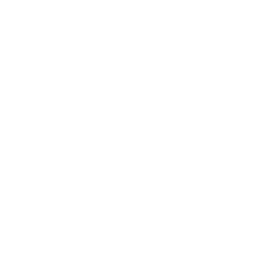
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnos av kemisk reaktorstörning</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identifiera variabler som driver reaktorns T²-överskridande under störningshändelse &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

En kontinuerligt omrörd tankreaktor (CSTR, Continuous Stirred-Tank
Reactor) gled in i en termisk störning när kylmedelsförsörjningen
försämrades. Under normal drift rör sig kylmedelsflödet,
reaktortemperaturen och manteltemperaturen tillsammans längs en enda
processlast-axel. Vi bygger en MVP-modell med tre komponenter på 100
observationer från normal drift, och poängsätter sedan 100
störningsobservationer mot den med `PROC MVPDIAGNOSE`. Att dela upp
Hotellings *T*-kvadrat-statistik i bidrag per variabel isolerar det
termiskt kopplade trion — `jacket_temp`, `coolant_flow` och
`reactor_temp` — som de variabler som driver överskridandet, vilket
pekar driftpersonalen direkt mot kylmedelssubsystemet.

## Datakällor

| Dataset | Roll | Observationer |
|---|---|---|
| `reactor_normal` | Träningsdata från normal drift för MVP-modellen | 100 |
| `reactor_upset` | Störningsobservationer som poängsätts mot modellen | 100 |

De fem uppmätta variablerna är `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) och `pressure` (bar).
Båda dataseten simuleras från en gemensam latent *processlast* så att
normaldata har samma korrelationsstruktur som en verklig CSTR uppvisar;
störningen inför ett kylmedelsbortfall som bryter den strukturen.

## Steg 1 — Träna MVP-modellen för normal drift

Normal drift styrs av en latent processlast: högre last drar ner
kylmedelsflödet samtidigt som den driver upp reaktor- och
manteltemperaturen. `PROC MVPMODEL` extraherar tre huvudkomponenter från
de 100 normala observationerna och sparar dem med `OUTMODEL=` så att
diagnossteget kan poängsätta ny data mot samma referens.

In [1]:
data reactor_normal;
  CALL streaminit(7);
  GÖR t = 1 TILL 100;
    load = rand('normal', 0, 1);                 /* latent processlast */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    UTDATA;
  SLUT;
KÖR;

PROCEDUR mvpmodel data=reactor_normal outmodel=reactor_model;
  VARIABEL reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
KÖR;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Steg 2 — Poängsätt störningshändelsen och dela upp *T*-kvadrat

Störningen sänker kylmedelsflödet med ungefär 12 L/min medan reaktor-
och manteltemperaturen stiger — den normala kopplingen mellan kylmedel
och temperatur är bruten. `PROC MVPDIAGNOSE` poängsätter varje
störningsobservation mot referensmodellen och skriver de
standardiserade poängen och residualerna till `OUT=` samt bidragen per
variabel till *T*-kvadrat till `OUTCONTRIB=`. Varje observation hamnar
långt utanför kontrollgränsen, vilket bekräftar en varaktig multivariat
avvikelse snarare än isolerat brus.

In [2]:
data reactor_upset;
  CALL streaminit(101);
  GÖR t = 1 TILL 100;
    load = rand('normal', 0, 1);
    /* Kylmedelspumpen försämras: flödet sjunker, temperaturerna skenar */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    UTDATA;
  SLUT;
KÖR;

PROCEDUR mvpdiagnose data=reactor_upset model=reactor_model
                 out=reactor_scores;
  VARIABEL reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
KÖR;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Steg 3 — Rangordna de genomsnittliga bidragen

`OUTCONTRIB=` skriver en rad per poängsatt observation med en
`<variable>_CONTRIB`-kolumn för varje processvariabel. Att beräkna
medelvärdet av dessa kolumner ger varje variabels genomsnittliga bidrag
till störningen; en transponering formar om den enradiga sammanfattningen
till en överskådlig variabel/värde-tabell som rangordnar
felorsakerna.

In [3]:
PROCEDUR MEDELVÄRDEN data=reactor_contrib mean NOPRINT;
  VARIABEL reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  UTDATA out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
KÖR;

PROCEDUR TRANSPOSE data=contrib_means out=contrib_long name=metric;
  VARIABEL mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
KÖR;

/* Kopplar läsbara variabelnamn och medelbidragsvärdet */
data contrib_ranked;
  STÄLL_IN contrib_long;
  LÄNGD variable $24;
  OM      metric = 'mc_reactor_temp' SÅ variable = 'Reaktortemperatur';
  ANNARS OM metric = 'mc_coolant_flow' SÅ variable = 'Kylmedelsflöde';
  ANNARS OM metric = 'mc_jacket_temp'  SÅ variable = 'Manteltemperatur';
  ANNARS OM metric = 'mc_feed_conc'    SÅ variable = 'Matningskoncentration';
  ANNARS OM metric = 'mc_pressure'     SÅ variable = 'Tryck';
  mean_contrib = col1;
  BEHÅLL variable mean_contrib;
KÖR;

PROCEDUR SORTERA data=contrib_ranked;
  EFTER FALLANDE mean_contrib;
KÖR;

PROCEDUR SKRIV data=contrib_ranked noobs ETIKETT;
  VARIABEL variable mean_contrib;
  ETIKETT variable='Processvariabel' mean_contrib='Genomsnittligt T²-bidrag';
KÖR;



      Processvariabel   Genomsnittligt T²-bidrag
---------------------  -------------------------
Manteltemperatur                   4177.66720283
Kylmedelsflöde                     2882.19501987
Reaktortemperatur                  1602.04200377
Tryck                               280.73140863
Matningskoncentration                61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/315cb482-5c44-408c-be89-a116ef18ec21/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Steg 4 — Bidragsdiagram

Bidragsdiagrammet gör diagnosen omedelbar: det termiskt kopplade trion
— `jacket_temp`, `coolant_flow` och `reactor_temp` — överskuggar
`feed_conc` och `pressure`, som knappt syns. De tre dominerande
staplarna är exakt de variabler som binds samman av kylkretsen, så
felet är entydigt termiskt och inte ett matnings- eller
tryckproblem.


NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


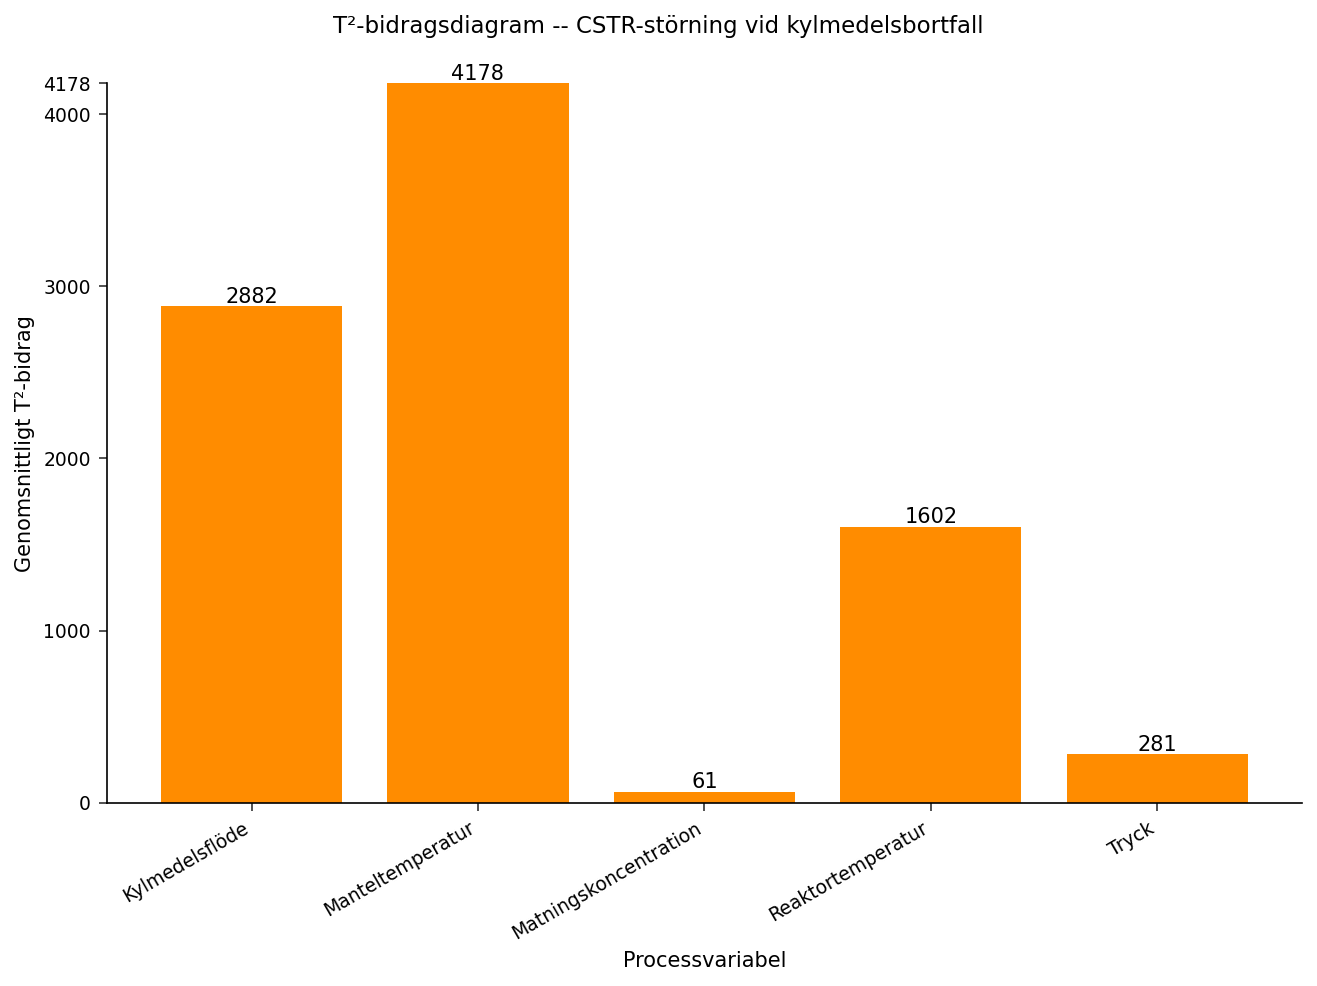

In [4]:
PROCEDUR SGPLOT data=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS ETIKETT='Processvariabel';
  YAXIS ETIKETT='Genomsnittligt T²-bidrag';
  TITEL 'T²-bidragsdiagram -- CSTR-störning vid kylmedelsbortfall';
KÖR;


## Steg 5 — Kontrolltidslinje för *T*-kvadrat

Att plotta varje observations *T*-kvadrat mot modellens kontrollgräns
visar att avvikelsen är kontinuerlig: varje störningsobservation ligger
storleksordningar över referenslinjen för gränsen. Ingen återhämtning
sker inom fönstret, vilket stämmer med ett hårdvarufel som kvarstår
tills kylmedelssubsystemet servas.


NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


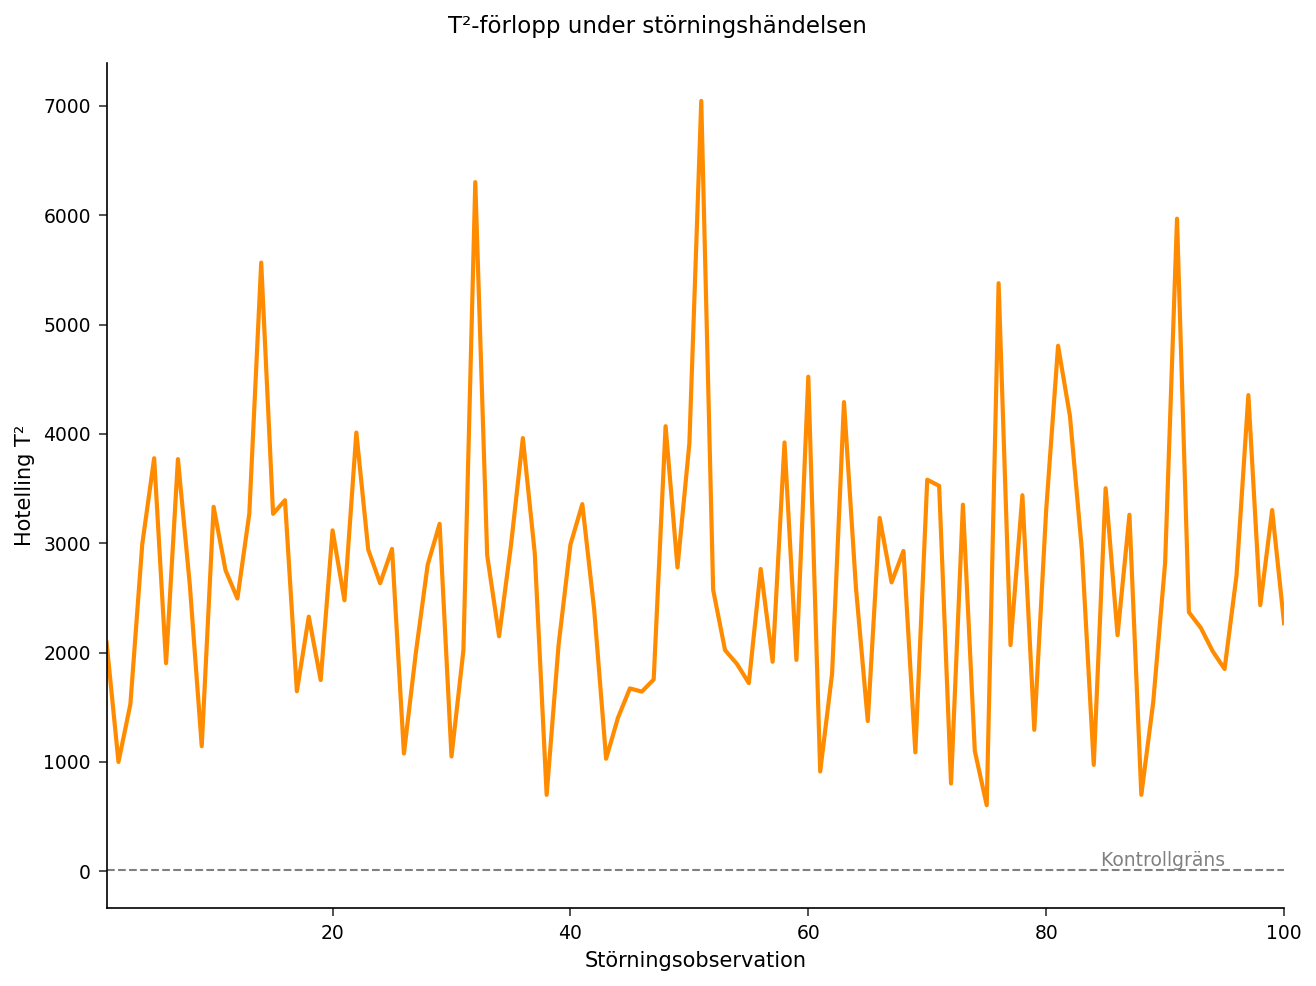

In [5]:
PROCEDUR SGPLOT data=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  ETIKETT='Kontrollgräns'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS ETIKETT='Störningsobservation';
  YAXIS ETIKETT='Hotelling T²';
  TITEL 'T²-förlopp under störningshändelsen';
KÖR;


## Resultat &amp; korrigerande åtgärd

- **Största drivkrafterna**: `jacket_temp`, `coolant_flow` och
  `reactor_temp` står tillsammans för praktiskt taget hela
  *T*-kvadrat-signalen; deras genomsnittliga bidrag är två till tre
  storleksordningar högre än `feed_conc` och `pressure`.
- **Grundorsak**: ett kylmedelsbortfall. `coolant_flow` är den enda
  *styrda* variabeln av de tre — temperaturökningarna är
  nedströmskonsekvenser av den förlorade kylningen, så det åtgärdbara
  felet finns i kylmedelssubsystemet.
- **Kontrollstatus**: alla 100 störningsobservationer överskrider
  *T*-kvadrat-gränsen, vilket tyder på en varaktig avvikelse snarare än
  en tillfällig.
- **Korrigerande åtgärd**: inspektera och renovera kylmedelspumpen;
  lägg till en redundant kylmedelsflödesgivare så att ett framtida
  försörjningsbortfall fångas upp av univariat larmning innan det
  sprider sig till temperaturkretsen.

## Exportera de rangordnade bidragen

Den rangordnade bidragstabellen skrivs till CSV för
efterhändelserapporten och nedströms-dashboards.

In [6]:
PROCEDUR EXPORTERA data=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>